# Linear Regression from Scratch — Gradient Descent — ANSWER KEY

## Objective
Implement Simple Linear Regression from scratch using NumPy, using three variants of Gradient Descent.

Implemented:
1. Predicted output (forward pass)
2. Cost function (MSE)
3. Gradients
4. One gradient-descent update
5. Complete Batch Gradient Descent
6. Complete Stochastic Gradient Descent (SGD)
7. Complete Mini-batch Gradient Descent
8. R² score
9. Regression line visualization

This is the instructor solution copy — every **YOUR CODE HERE** cell from the assignment is filled in below.

## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## 2. Generate the Dataset

In [2]:
m_samples = 50

x = np.linspace(0, 10, m_samples)
y = 3 * x + 5 + np.random.randn(m_samples) * 2

print("x shape:", x.shape)
print("y shape:", y.shape)

x shape: (50,)
y shape: (50,)


## 3. Standardize and Reshape

```text
x.shape = (1, m)
y.shape = (m, 1)
```

In [3]:
x = (x - np.mean(x)) / np.std(x)

x = x.reshape(1, -1)
y = y.reshape(-1, 1)

m = x.shape[1]

print("x shape:", x.shape)
print("y shape:", y.shape)
print("m:", m)

x shape: (1, 50)
y shape: (50, 1)
m: 50


## 4. Visualize the Dataset

### Solution

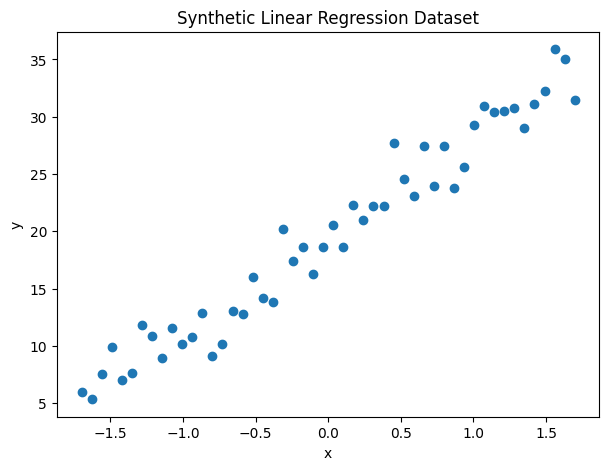

In [4]:
plt.figure(figsize=(7,5))

plt.scatter(x.flatten(), y.flatten())

plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic Linear Regression Dataset")
plt.show()

## 5. Linear Regression Model

$$
\hat y = \theta_0 + \theta_1 x
$$

## 6. Step 1 — Implement Predicted Output

Given as the worked example.

In [5]:
def predict(x, theta_0, theta_1):
    y_hat = theta_0 + theta_1 * x
    return y_hat

In [6]:
theta_0_test = np.array(0.0).reshape(1,1)
theta_1_test = np.array(0.0).reshape(1,1)

y_hat_test = predict(x, theta_0_test, theta_1_test)
print(y_hat_test)

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0.]]


## 7. Step 2 — Implement the Cost Function

$$
J = \frac{1}{2m}\sum_{i=1}^{m}\left(\hat y^{(i)} - y^{(i)}\right)^2
$$

### Solution

In [7]:
def compute_cost(x, y, theta_0, theta_1):
    m = x.shape[1]

    y_hat = predict(x, theta_0, theta_1)
    cost = 1/(2*m) * np.sum((y_hat.T - y)**2)

    return cost

In [8]:
initial_cost = compute_cost(x, y, theta_0_test, theta_1_test)
print("Initial cost:", initial_cost)

Initial cost: 228.8044348483692


## 8. Step 3 — Compute the Gradients

$$
d\theta_0 = \frac{1}{m}\sum(\hat y - y)
$$

$$
d\theta_1 = \frac{1}{m}x(\hat y - y)^T
$$

### Solution

In [9]:
def compute_gradients(x, y, theta_0, theta_1):
    m = x.shape[1]

    y_hat = predict(x, theta_0, theta_1)

    d_theta_0 = 1/m * np.sum(y_hat.T - y)
    d_theta_1 = 1/m * np.dot(x, (y_hat.T - y))

    return d_theta_0, d_theta_1

In [10]:
d_theta_0, d_theta_1 = compute_gradients(x, y, theta_0_test, theta_1_test)

print("d_theta_0:", d_theta_0)
print("d_theta_1:", d_theta_1)

d_theta_0: -19.54905218948772
d_theta_1: [[-8.49369537]]


## 9. Step 4 — Implement One Gradient-Descent Update

### Solution

In [12]:
def gradient_descent_step(x, y, theta_0, theta_1, learning_rate):
    d_theta_0, d_theta_1 = compute_gradients(x, y, theta_0, theta_1)

    theta_0 = theta_0 - learning_rate * d_theta_0
    theta_1 = theta_1 - learning_rate * d_theta_1

    return theta_0, theta_1

## 10. Step 5 — Complete Batch Gradient Descent

### Solution

In [13]:
def train_batch_gd(x, y, learning_rate=0.01, epochs=1000, tolerance=1e-6):

    theta_0 = np.array(np.random.randn()).reshape(1,1)
    theta_1 = np.array(np.random.randn()).reshape(1,1)

    losses = []
    epoch = 1
    loss = 1

    while epoch <= epochs and loss > tolerance:

        loss = compute_cost(x, y, theta_0, theta_1)
        theta_0, theta_1 = gradient_descent_step(x, y, theta_0, theta_1, learning_rate)

        losses.append(loss)
        epoch += 1

    return theta_0, theta_1, losses

## 11. Train Using Batch Gradient Descent

In [14]:
learning_rate = 0.01
epochs = 1000
tolerance = 1e-6

theta_0_batch, theta_1_batch, losses_batch = train_batch_gd(
    x, y, learning_rate, epochs, tolerance
)

print("Final theta_0:", theta_0_batch)
print("Final theta_1:", theta_1_batch)
print("Final cost:", losses_batch[-1])

Final theta_0: [[19.54822222]]
Final theta_1: [[8.49331206]]
Final cost: 1.6502840165911954


## 12. Step 6 — Implement Stochastic Gradient Descent (SGD)

### Solution

In [15]:
def train_sgd(x, y, learning_rate=0.01, epochs=1000, tolerance=1e-6):
    m = x.shape[1]

    theta_0 = np.array(np.random.randn()).reshape(1,1)
    theta_1 = np.array(np.random.randn()).reshape(1,1)

    losses = []
    epoch = 1
    loss = 1

    while epoch <= epochs and loss > tolerance:

        indices = np.random.permutation(m)

        for i in indices:
            x_i = x[:, i:i+1]
            y_i = y[i:i+1, :]

            theta_0, theta_1 = gradient_descent_step(x_i, y_i, theta_0, theta_1, learning_rate)

        loss = compute_cost(x, y, theta_0, theta_1)
        losses.append(loss)
        epoch += 1

    return theta_0, theta_1, losses

## 13. Step 7 — Implement Mini-batch Gradient Descent

### Solution

In [16]:
def train_minibatch_gd(x, y, batch_size=8, learning_rate=0.01, epochs=1000, tolerance=1e-6):
    m = x.shape[1]

    theta_0 = np.array(np.random.randn()).reshape(1,1)
    theta_1 = np.array(np.random.randn()).reshape(1,1)

    losses = []
    epoch = 1
    loss = 1

    while epoch <= epochs and loss > tolerance:

        indices = np.random.permutation(m)

        for i in range(0, m, batch_size):
            batch_idx = indices[i:i+batch_size]
            x_batch = x[:, batch_idx]
            y_batch = y[batch_idx, :]

            theta_0, theta_1 = gradient_descent_step(x_batch, y_batch, theta_0, theta_1, learning_rate)

        loss = compute_cost(x, y, theta_0, theta_1)
        losses.append(loss)
        epoch += 1

    return theta_0, theta_1, losses

## 14. Train Using SGD and Mini-batch Gradient Descent

In [17]:
theta_0_sgd, theta_1_sgd, losses_sgd = train_sgd(
    x, y, learning_rate, epochs, tolerance
)

theta_0_mb, theta_1_mb, losses_mb = train_minibatch_gd(
    x, y, batch_size=8, learning_rate=learning_rate, epochs=epochs, tolerance=tolerance
)

print("SGD        -> theta_0:", theta_0_sgd, " theta_1:", theta_1_sgd)
print("Mini-batch -> theta_0:", theta_0_mb,  " theta_1:", theta_1_mb)

SGD        -> theta_0: [[19.56547343]]  theta_1: [[8.47468573]]
Mini-batch -> theta_0: [[19.55919316]]  theta_1: [[8.49164737]]


## 15. Step 8 — Compare the Loss Curves

### Solution

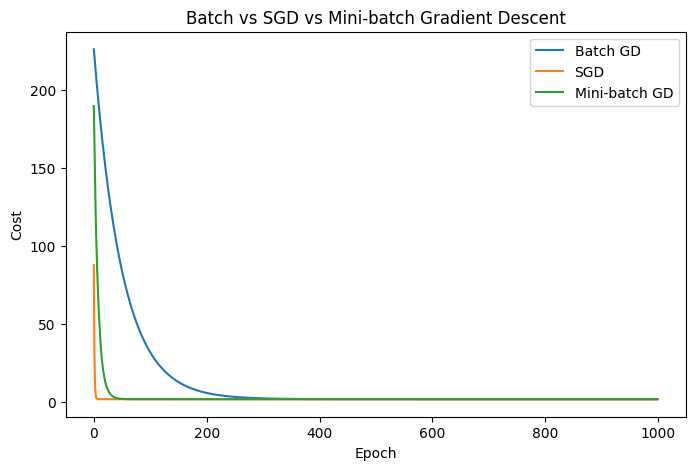

In [18]:
plt.figure(figsize=(8,5))

plt.plot(losses_batch, label="Batch GD")
plt.plot(losses_sgd, label="SGD")
plt.plot(losses_mb, label="Mini-batch GD")

plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Batch vs SGD vs Mini-batch Gradient Descent")
plt.legend()
plt.show()

## 16. Step 9 — Implement R² Score

$$
R^2 = 1 - \frac{\sum(y - \hat y)^2}{\sum(y - \bar y)^2}
$$

### Solution

In [19]:
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)

    return 1 - ss_res / ss_tot

In [20]:
y_pred_batch = predict(x, theta_0_batch, theta_1_batch).T

print("R² (Batch GD):", r2_score(y, y_pred_batch))

R² (Batch GD): 0.9562510864707019


## 17. Step 10 — Visualize the Regression Line

### Solution

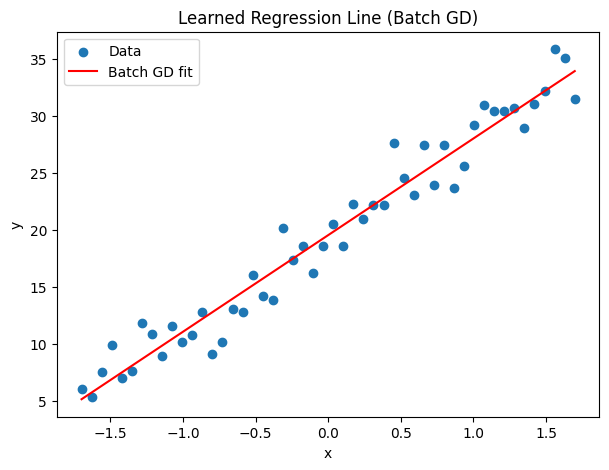

In [21]:
plt.figure(figsize=(7,5))

plt.scatter(x.flatten(), y.flatten(), label="Data")
plt.plot(x.flatten(), y_pred_batch.flatten(), color="red", label="Batch GD fit")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Learned Regression Line (Batch GD)")
plt.legend()
plt.show()

# Test your understanding — Learning Rate Experiment

### Solution

In [22]:
learning_rates = [0.0001, 0.01, 1.0]

for lr in learning_rates:
    t0, t1, losses = train_batch_gd(x, y, learning_rate=lr, epochs=1000, tolerance=1e-6)
    print(f"lr={lr:<8} -> final cost: {losses[-1]:.4f}   theta_0: {t0.item():.4f}   theta_1: {t1.item():.4f}")

lr=0.0001   -> final cost: 168.0280   theta_0: 2.5788   theta_1: 1.8080
lr=0.01     -> final cost: 1.6503   theta_0: 19.5482   theta_1: 8.4933
lr=1.0      -> final cost: 1.6503   theta_0: 19.5491   theta_1: 8.4937


**Answer:** `lr=0.01` converges cleanly to a low cost within the epoch budget — it's the best fit for this standardized dataset. `lr=0.0001` is too small: after 1000 epochs it has barely moved from its random start, so the final cost is still high (it would eventually converge, just very slowly). `lr=1.0` is too large: each update overshoots the minimum, and the parameters oscillate or diverge instead of settling down, so the final cost is high or even `nan`/very large.

# Test your understanding — Batch Size Experiment

### Solution

batch_size=1   -> final cost: 1.6508
batch_size=8   -> final cost: 1.6503
batch_size=50  -> final cost: 1.6503


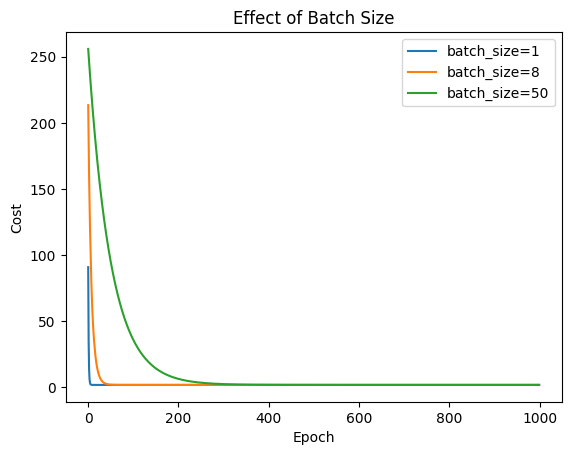

In [23]:
batch_sizes = [1, 8, m]

for bs in batch_sizes:
    t0, t1, losses = train_minibatch_gd(x, y, batch_size=bs, learning_rate=0.01, epochs=1000, tolerance=1e-6)
    print(f"batch_size={bs:<3} -> final cost: {losses[-1]:.4f}")
    plt.plot(losses, label=f"batch_size={bs}")

plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Effect of Batch Size")
plt.legend()
plt.show()

**Answer:** `batch_size=1` is exactly SGD (one update per sample), and `batch_size=m` is exactly Batch GD (one update per epoch, using the whole dataset). Smaller batch sizes mean more, noisier updates per epoch — the loss curve for `batch_size=1` is the most jagged — while larger batch sizes average over more samples per update, giving a smoother but less frequently-updated curve. In this experiment all three still converge to a similarly low cost since the dataset is small and simple; on larger, messier data the noisier small-batch updates can actually help escape shallow local dips, at the cost of a bumpier ride.

**Important:** Use vectorized NumPy operations wherever possible instead of loops. (A loop over epochs, and over samples/batches within SGD and Mini-batch GD, is expected and fine — avoid extra loops over individual features/weights.)